<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# Simple Linear Regression


## Objectives

After completing this lab, you will be able to:

* Use scikit-learn to implement simple linear regression
* Create, train, and test a linear regression model on real data


### Import needed packages


For this lab, you will need to have the following packages:
 - NumPy
 - Matplotlib
 - Pandas
 - Scikit-learn

To avoid issues importing these libraries, you may execute the following cell to ensure they are available.


Now, you can import these libraries.


In [1]:
from statistics import mean

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

pd.set_option('display.width', None) # disable  width limite 
pd.set_option('display.max_columns',None) # display all columns on one line 


## Load the data
The dataset you will use resides at the following URL. You can use the URL directly with the Pandas library to load the dataset.


In [2]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

In [3]:
df = pd.read_csv(url)


## Understand the data

### `FuelConsumption.csv`:
You will use a fuel consumption dataset, **`FuelConsumption.csv`**, which contains model-specific fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada. [Dataset source](http://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64).

- **MODEL YEAR** e.g. 2014
- **MAKE** e.g. VOLVO
- **MODEL** e.g. S60 AWD
- **VEHICLE CLASS** e.g. COMPACT
- **ENGINE SIZE** e.g. 3.0
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. AS6
- **FUEL TYPE** e.g. Z
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 13.2
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 9.5
- **FUEL CONSUMPTION COMBINED (L/100 km)** e.g. 11.5
- **FUEL CONSUMPTION COMBINED MPG (MPG)** e.g. 25
- **CO2 EMISSIONS (g/km)** e.g. 182 

Your task will be to create a simple linear regression model from one of these features to predict CO2 emissions of unobserved cars based on that feature. 


### Explore the data
First, consider a statistical summary of the data.


In [4]:
df.describe() # to ssee all the describtion of the data
# count -> is all my dataset lines
#mean -> the average of all the dataset
# std -> tells me how far the data is from the mean
# min -> minimum value in the column
#25% -> 25% of cars or 1/4 has the df[features] of value or less
#50% -> 50% of cars or 1/2 has the df[features] of value or less
#75% -> 75% of cars or 1/3 has the df[features] of value or less
# max -> maximum value in the column

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


#### Select features
Select a few features that might be indicative of CO2 emission to explore more.


In [5]:
# select only numeric data types since our goal is the prediction of a continuous number
corr_matrix = df.select_dtypes(include = ["number"]).corr()


In [6]:
#features that might be indicative of CO2 emission

corr_matrix['CO2EMISSIONS'].abs().sort_values(ascending = False)
# abs(): convert all negatives  value into positives e.g -0.85 becomes 0.85


CO2EMISSIONS                1.000000
FUELCONSUMPTION_COMB_MPG    0.906394
FUELCONSUMPTION_CITY        0.898039
FUELCONSUMPTION_COMB        0.892129
ENGINESIZE                  0.874154
FUELCONSUMPTION_HWY         0.861748
CYLINDERS                   0.849685
MODELYEAR                        NaN
Name: CO2EMISSIONS, dtype: float64

#### Visualize features
Consider the histograms for each of these features.


As you can see, most engines have 4, 6, or 8 cylinders, and engine sizes between 2 and 4 liters.  
As you might expect, combined fuel consumption and CO2 emission have very similar distributions.  
Go ahead and display some scatter plots of these features against the CO2 emissions, to see how linear their relationships are.


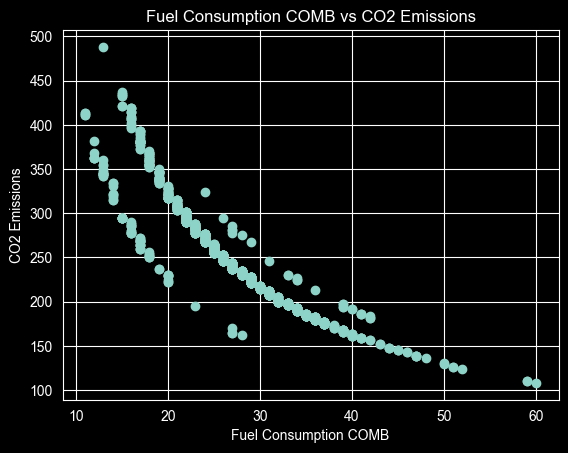

In [7]:
plt.scatter(df['FUELCONSUMPTION_COMB_MPG'],df['CO2EMISSIONS'])
plt.xlabel("Fuel Consumption COMB")
plt.ylabel("CO2 Emissions")
plt.title("Fuel Consumption COMB vs CO2 Emissions")
plt.show()


###### This relation between FUELCONSUMPTION_COMB and CO2 is not linear

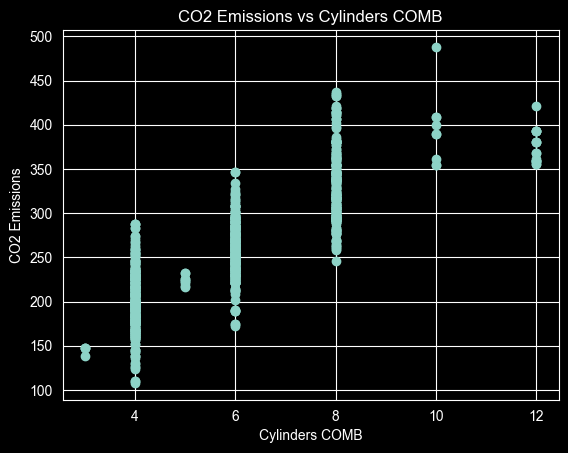

In [8]:
plt.scatter(df['CYLINDERS'],df['CO2EMISSIONS'])
plt.xlabel("Cylinders COMB")
plt.ylabel("CO2 Emissions")
plt.title("CO2 Emissions vs Cylinders COMB")
plt.show()

###### This relation between CYLINDERS and CO2 is linear


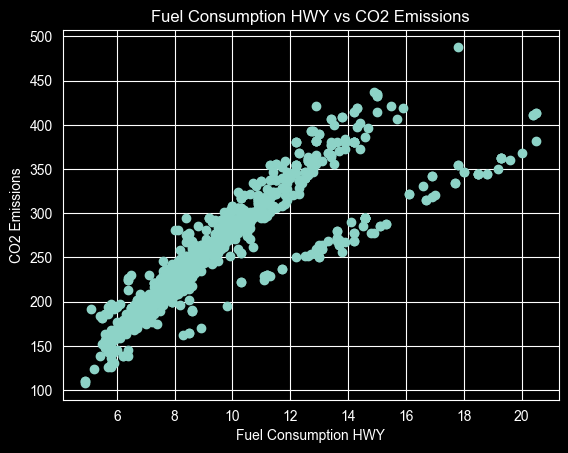

In [9]:
plt.scatter(df['FUELCONSUMPTION_HWY'],df['CO2EMISSIONS'])
plt.xlabel("Fuel Consumption HWY")
plt.ylabel("CO2 Emissions")
plt.title("Fuel Consumption HWY vs CO2 Emissions")
plt.show()

###### This relation between FUELCONSUMPTION_HWY and CO2 is linear


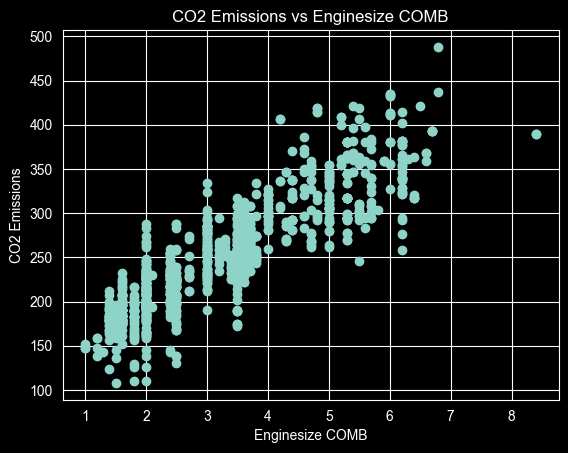

In [10]:
plt.scatter(df['ENGINESIZE'],df['CO2EMISSIONS'])
plt.xlabel("Enginesize COMB")
plt.ylabel("CO2 Emissions")
plt.title("CO2 Emissions vs Enginesize COMB")
plt.show()

###### This relation between ENGINESIZE and CO2 is linear

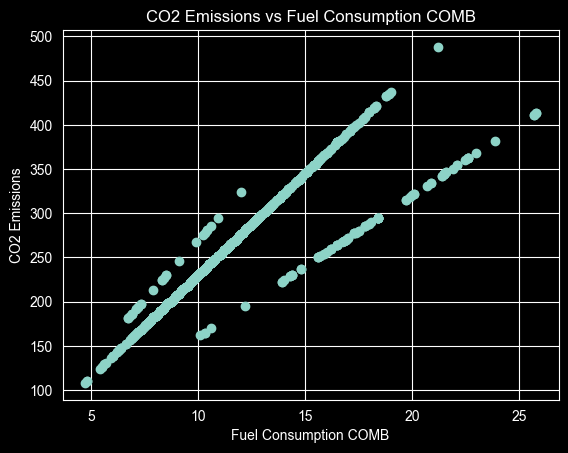

In [11]:
plt.scatter(df['FUELCONSUMPTION_COMB'],df['CO2EMISSIONS'])
plt.xlabel("Fuel Consumption COMB")
plt.ylabel("CO2 Emissions")
plt.title("CO2 Emissions vs Fuel Consumption COMB")
plt.show()

###### This relation between FUELCONSUMPTION_COMB and CO2 is linear


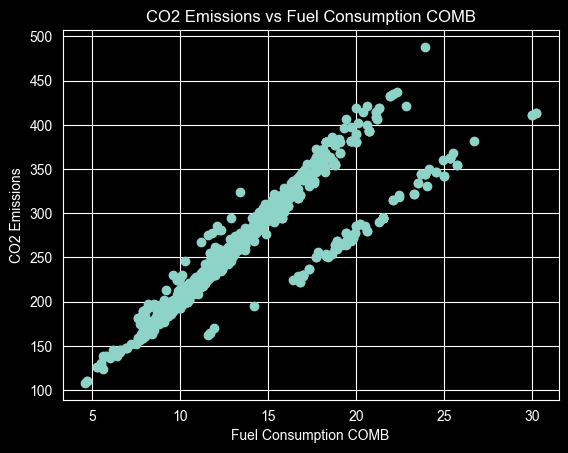

In [12]:
plt.scatter(df['FUELCONSUMPTION_CITY'],df['CO2EMISSIONS'])
plt.xlabel("Fuel Consumption COMB")
plt.ylabel("CO2 Emissions")
plt.title("CO2 Emissions vs Fuel Consumption COMB")
plt.show()

This is an informative result. Three car groups each have a strong linear relationship between their combined fuel consumption and their CO2 emissions. 
Their intercepts are similar, while they noticeably differ in their slopes.


Although the relationship between engine size and CO2 emission is quite linear, you can see that their correlation is weaker than that for each of the three fuel consumption groups. Notice that the x-axis range has been expanded to make the two plots more comparable.


#### Practice excercise 1
Plot __CYLINDER__ against CO2 Emission, to see how linear their relationship is.


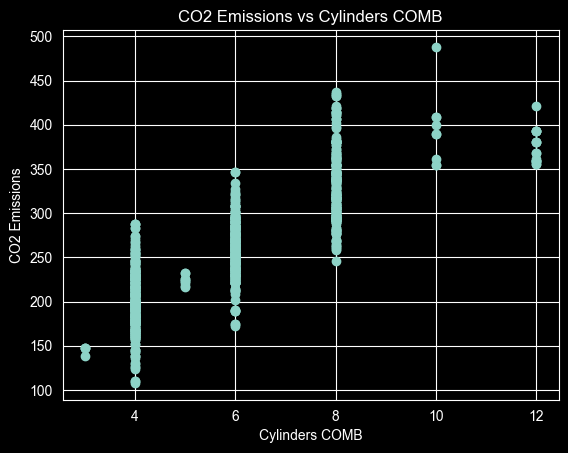

In [13]:
plt.scatter(df['CYLINDERS'],df['CO2EMISSIONS'])
plt.xlabel("Cylinders COMB")
plt.ylabel("CO2 Emissions")
plt.title("CO2 Emissions vs Cylinders COMB")

plt.show()

<details><summary>Click here for the solution</summary>

```python    
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("CYLINDERS")
plt.ylabel("CO2 Emission")
plt.show()

```

</details>


### Extract the input feature and labels from the dataset
Although perhaps not necessarily the ideal choice of input feature, for illustration purposes, you will use engine size to predict CO2 emission with a linear regression model.  
You can begin the process by extracting the input feature and target output variables, X and y, from the dataset.


In [14]:
X = np.array(df['CYLINDERS']).reshape(-1,1)
y = np.array(df['CO2EMISSIONS'])

print(y.shape)

(1067,)


#### Create train and test datasets
Next, you will split the dataset into mutually exclusive training and testing sets. You will train a simple linear regression model on the training set and estimate its ability to generalize to unseen data by using it to make predictions on the unseen testing data. 

Since the outcome of each data point is part of the testing data, you have a means of evaluating the out-of-sample accuracy of your model.

Now, you want to randomly split your data into train and test sets, using 80% of the dataset for training and reserving the remaining 20% for testing. Which fraction to use here mostly depends on the size of your data, but typical testing sizes range from 20% to 30%. The smaller your data, the larger your training set needs to be because it's easier to find spurious patterns in smaller data. The downside is that your evaluation of generalizability will have less reliability. Bigger is better when it comes to data.


In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

The outputs are one-dimensional NumPy arrays or vectors.


### Build a simple linear regression model

You'll use scikit-learn to build your model as follows. See [Scikit-Learn Linear Regression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) to learn all about the linear model predictor object.


In [16]:
# Model selection
model = LinearRegression()
#train model
model.fit(X_train,y_train)

LinearRegression()

In [17]:
# Model params
coef = model.coef_[0] # [0] because I .coef gives an array of features, and i just want the exact value of the unique feature that i have which is CYLINDERS
print(coef)
#

29.478398786995275


coef = 29.478398786995275, mean that for any additional 1 unit add for CYLINDERS, that correspond at arround 29.47 g/km of  CO2 Emissions.

In [18]:
intercept = model.intercept_
print(intercept)

86.08850036109311


intercept = 86.08850036109416, mean that a car with 0 CYLINDERS would produice 86.08850036109416 g/km of CO2. But a car with 0 CYLINDERS does not exist. So then In this case this intercept is use as a constante to create the line. 

In [19]:
y_pred = model.predict(X_test)
print(y_pred)

[321.91569066 262.95889308 262.95889308 262.95889308 204.00209551
 262.95889308 262.95889308 262.95889308 321.91569066 262.95889308
 262.95889308 439.82928581 262.95889308 262.95889308 262.95889308
 262.95889308 204.00209551 262.95889308 204.00209551 321.91569066
 321.91569066 204.00209551 262.95889308 262.95889308 262.95889308
 204.00209551 204.00209551 204.00209551 321.91569066 262.95889308
 321.91569066 204.00209551 204.00209551 321.91569066 262.95889308
 321.91569066 321.91569066 321.91569066 204.00209551 204.00209551
 204.00209551 204.00209551 204.00209551 204.00209551 262.95889308
 204.00209551 262.95889308 262.95889308 204.00209551 380.87248823
 321.91569066 262.95889308 204.00209551 262.95889308 262.95889308
 321.91569066 321.91569066 321.91569066 204.00209551 262.95889308
 321.91569066 262.95889308 321.91569066 262.95889308 204.00209551
 262.95889308 204.00209551 321.91569066 262.95889308 262.95889308
 321.91569066 204.00209551 262.95889308 204.00209551 204.00209551
 262.95889

# interpretations
- Mathematically, predict() function calculate (y_pred) at each point of (X_test), Following y_pred = b0 + X*b1, where b0 is the intercept and X the feature and b1 the slope.
- The fact that we are same value in the output means that, we have in the input data similar value.
- To know if the predictions are good i will compare this prediction (y_pred) with the real test set data (y_test)


In [20]:
## Evaluation
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error


R2 = r2_score(y_test, y_pred)

MSE = mean_squared_error(y_test, y_pred)

MAE = mean_absolute_error(y_test, y_pred)

print(f"R2: {R2}.  "f"Model is acceptable")
print(f"MSE: {MSE}. "f"Penality for error")
print(f"MAE: {MAE}.",
      f"The model makes mistake in the average of {MAE} of CO2")

R2: 0.7317140029783893.  Model is acceptable
MSE: 1109.347975406245. Penality for error
MAE: 25.714927648305263. The model makes mistake in the average of 25.714927648305263 of CO2


### Visualize model outputs


You can visualize the goodness-of-fit of the model to the training data by plotting the fitted line over the data.

The regression model is the line given by y = intercept + coefficient * x.


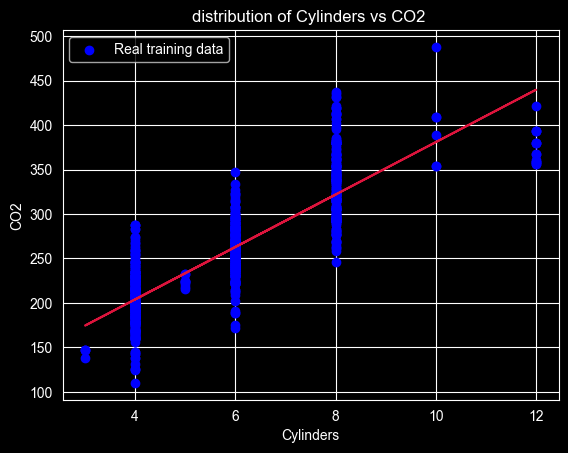

In [21]:
plt.scatter(X_train, y_train, color = "b",label = "Real training data")
plt.plot(X_train, model.predict(X_train), color="crimson")
plt.xlabel("Cylinders")
plt.ylabel("CO2")
plt.legend()
plt.title("distribution of Cylinders vs CO2 ")

plt.show()


## Practice exercises


#### 1. Plot the regression model result over the test data instead of the training data. Visually evaluate whether the result is good.


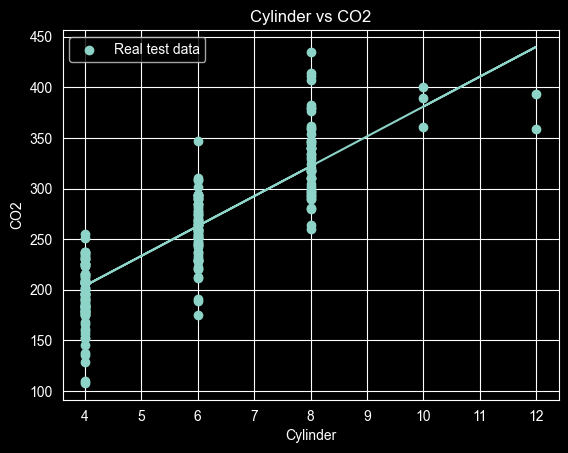

In [22]:
plt.scatter(X_test,y_test,label = "Real test data")
plt.plot(X_test, y_pred) 
plt.xlabel("Cylinder")
plt.ylabel("CO2")
plt.title("Cylinder vs CO2")
plt.legend()
plt.show()

## interpretation
we can see that the model is generalizing well and there is not overtiffing

<details><summary>Click here for the solution</summary>
```python    
plt.scatter(X_test, y_test,  color='blue')
plt.plot(X_test, regressor.coef_ * X_test + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
```

</details>


Let's see the evaluation metrics if you train a regression model using the `FUELCONSUMPTION_COMB` feature.

#### 2. Select the fuel consumption feature from the dataframe and split the data 80%/20% into training and testing sets. 
Use the same random state as previously so you can make an objective comparison to the previous training result.


In [23]:
# Sélection de la nouvelle feature et de la cible
X_fuel = np.array(df[['FUELCONSUMPTION_COMB']]) # Pas besoin de reshape si tu mets deux crochets [[]]
y_fuel = df['CO2EMISSIONS']

# Le split 80% / 20%
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_fuel, y_fuel, test_size=0.2, random_state=42)


#### 3.  Train a linear regression model using the training data you created.
Remember to transform your 1D feature into a 2D array. 

In [24]:
model_3 = LinearRegression()
model_3.fit(X_train_f, y_train_f) # On utilise bien le train du FUEL ici !


LinearRegression()

<details><summary>Click here for the solution</summary>

```python    
regr = linear_model.LinearRegression()
regr.fit(X_train.reshape(-1, 1), y_train)

```

</details>


#### 4. Use the model to make test predictions on the fuel consumption testing data.


In [25]:
y_pred_3 = model_3.predict(X_test_f)
print(y_pred_3)


[282.69091649 224.43967368 276.21855618 224.43967368 214.73113321
 242.23866454 331.23361884 287.54518673 287.54518673 336.08788907
 302.10799743 345.79642954 250.32911493 242.23866454 258.41956532
 248.71102485 232.53012407 239.00248438 198.55023243 279.45473634
 303.72608751 221.20349352 256.80147524 234.14821415 269.74619587
 206.64068282 216.34922329 192.07787212 277.83664626 243.85675462
 418.61048305 206.64068282 221.20349352 318.28889821 229.29394391
 255.18338516 251.94720501 434.79138383 206.64068282 206.64068282
 175.89697134 193.6959622  196.93214235 214.73113321 281.07282641
 214.73113321 240.62057446 264.89192563 195.31405227 350.65069977
 274.6004661  285.92709665 227.67585384 266.51001571 274.6004661
 292.39945696 416.99239298 297.25372719 193.6959622  272.98237602
 294.01754704 260.0376554  266.51001571 245.47484469 203.40450266
 235.76630423 195.31405227 276.21855618 256.80147524 258.41956532
 352.26878985 201.78641259 255.18338516 221.20349352 230.91203399
 308.580357

<details><summary>Click here for the solution</summary>

```python    
y_pred= regr.predict(X_test.reshape(-1,1))

```

</details>


#### 5. Calculate and print the Mean Squared Error of the test predictions.


In [26]:
from sklearn.metrics import mean_squared_error
MSE = mean_squared_error(y_test,y_pred_3)
print(MSE)

797.4346310097205


### Congratulations! You're ready to move on to your next lesson.
 
 
## Author
<a href="https://www.linkedin.com/in/jpgrossman/" target="_blank">Jeff Grossman</a>  
 
 ### Other Contributors
 <a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" target="_blank">Abhishek Gagneja</a>

 ## <h3 align="center"> © IBM Corporation. All rights reserved. <h3/>

<!--
## Changelog
| Date | Version | Changed by | Change Description |
|------------|------|------------------|---------------------------------------|
| 2024-07-26 | 3.0  | Jeff Grossman    | Update content and practice exercises |
| 2020-11-03 | 2.1  | Lakshmi Holla    | Change URL of the csv |
| 2020-08-27 | 2.0  | Lavanya          | Move lab to course repo in GitLab |






LES QUESTIONS pour LinearRegression
## Version que je proposerais

L'exercice pourrait être structuré ainsi :

1. Charger les données.
2. Séparer les données (`train_test_split`).
3. Entraîner une régression linéaire.
4. Afficher la pente et l'intercept.
5. Calculer R².
6. Calculer MAE et RMSE.
7. Tracer la droite de régression.
8. Prédire pour 30 kAED.
9. Répondre aux questions de compréhension :

   * interprétation de la pente ;
   * interprétation de l'intercept ;
   * taille du jeu de test ;
   * extrapolation ;
   * limites du modèle linéaire ;
   * effet d'un point aberrant ;
   * signification du R² ;
   * pourquoi les résidus sont importants.



LES QUESTIONS pour LinearRegression
